# 0. Importar librerias

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Cargar el dataset real

In [14]:
df = pd.read_csv('Fact_Desapariciones.csv')

/tmp/ipykernel_4134/2913484679.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Fact_Desapariciones.csv')


# 2. Crear la variable objetivo: 1 si es 'EN INVESTIGACIÓN' (Riesgo Crítico), 0 si ya se solucionó

In [15]:
df['target_riesgo'] = np.where(df['estado_desaparecido'] == 'EN INVESTIGACIÓN', 1, 0)

# 3. Seleccionar las variables predictoras (Features) y limpiar
## Usamos columnas categóricas demográficas y geográficas presentes en tu CSV

In [16]:
features = ['sexo', 'edad', 'circuito']
X = df[features].copy()
y = df['target_riesgo']

# Codificar las variables de texto a números para el algoritmo

In [17]:
le_sexo = LabelEncoder()
X['sexo'] = le_sexo.fit_transform(X['sexo'].astype(str))

le_circuito = LabelEncoder()
X['circuito'] = le_circuito.fit_transform(X['circuito'].astype(str))

# 4. Dividir el dataset en entrenamiento (80%) y prueba (20%)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Entrenar el modelo de Árbol de Decisión equilibrando los pesos por el sesgo histórico

In [19]:
model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

# 6. Realizar las predicciones de evaluación

In [20]:
y_pred = model.predict(X_test)

# 7. Graficar la Matriz de Confusión de alta calidad para la captura

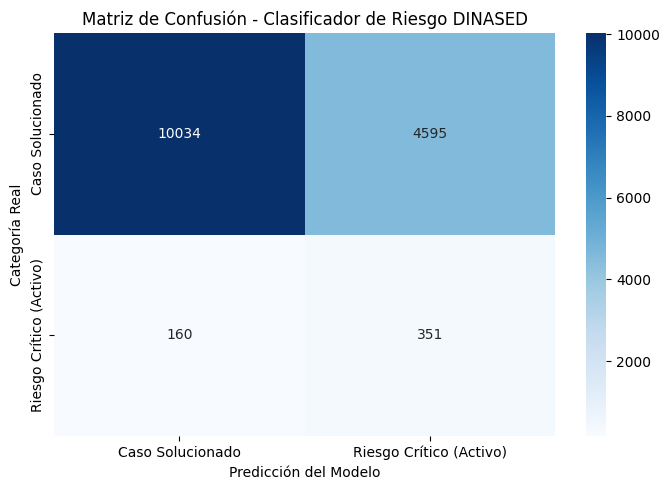

In [21]:
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Caso Solucionado', 'Riesgo Crítico (Activo)'],
            yticklabels=['Caso Solucionado', 'Riesgo Crítico (Activo)'])
plt.title('Matriz de Confusión - Clasificador de Riesgo DINASED')
plt.ylabel('Categoría Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=300)
plt.show()

# 8. Imprimir el reporte técnico de métricas en la consola

In [22]:
print("\n=== REPORTE DE CLASIFICACIÓN OPERATIVA ===")
print(classification_report(y_test, y_pred, target_names=['Caso Solucionado', 'Riesgo Crítico']))


=== REPORTE DE CLASIFICACIÓN OPERATIVA ===
                  precision    recall  f1-score   support

Caso Solucionado       0.98      0.69      0.81     14629
  Riesgo Crítico       0.07      0.69      0.13       511

        accuracy                           0.69     15140
       macro avg       0.53      0.69      0.47     15140
    weighted avg       0.95      0.69      0.79     15140



# 9. Mostrar la importancia de las variables (Gobernanza / IA Explicable)

In [23]:
importances = model.feature_importances_
for name, importance in zip(features, importances):
    print(f"Variable: {name:10} -> Importancia en la decisión: {importance*100:.2f}%")

Variable: sexo       -> Importancia en la decisión: 60.75%
Variable: edad       -> Importancia en la decisión: 27.32%
Variable: circuito   -> Importancia en la decisión: 11.92%
